## Import Libraries

In [ ]:
import pandas as pd
import numpy as np
from sklearn import ensemble, metrics
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
%matplotlib inline

# Needed to hide warnings in the matplotlib sections
import warnings
warnings.filterwarnings("ignore")

## Importing the dataset

In [7]:
df = pd.read_csv("../../dataSet/marketing_and_sales_clean.csv")

## Splitting the dataset into the Training set and Test set

In [8]:
X = df[["TV", "Radio", "Influencer", "Social Media"]].values
y = df[["Sales"]].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

params = {
    "n_estimators": 500,
    "max_depth": 4,
    "min_samples_split": 5,
    "learning_rate": 0.01,
    "loss": "squared_error",
}

## Training

In [9]:
reg = ensemble.GradientBoostingRegressor(**params)
reg.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.01, max_depth=4, min_samples_split=5,
                          n_estimators=500)

In [10]:
predictions = reg.predict(X_test)

Text(0, 0.5, 'Predicted Y')

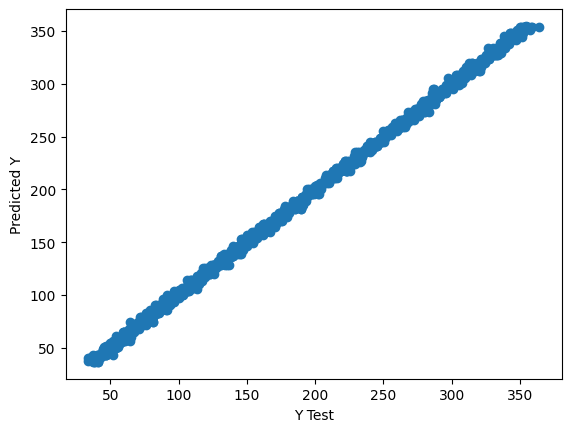

In [12]:
plt.scatter(y_test,predictions)
plt.xlabel('Y Test')
plt.ylabel('Predicted Y')

In [ ]:
MAE = metrics.mean_absolute_error(y_test, predictions)
MSE = metrics.mean_squared_error(y_test, predictions)
RMSE = metrics.root_mean_squared_error(y_test, predictions)
R2 = metrics.r2_score(y_test, predictions)
print(f"MAE : {MAE}\nMSE : {MSE}\nRMSE : {RMSE}\nR2 : {R2}\n")

MAE : 2.4709865941037354
MSE : 9.707541104783711
RMSE : 3.1156927166817514
R2 : 0.9988867060148158



## Export model

In [ ]:
import pickle

# save
with open('../saved_models/gradient_boosting/model.pkl','wb') as f:
    pickle.dump(reg,f)